In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [4]:
# Select numerical columns
numeric_columns = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

# Mean
print("MEAN:")
print(df[numeric_columns].mean())

# Median
print("\nMEDIAN:")
print(df[numeric_columns].median())

# Mode
print("\nMODE:")
print(df[numeric_columns].mode().iloc[0])

# Standard Deviation
print("\nSTANDARD DEVIATION:")
print(df[numeric_columns].std())

MEAN:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

MEDIAN:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

MODE:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

STANDARD DEVIATION:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [5]:
summary = df[numeric_columns].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0


In [6]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check the data type
print(df['Date'].dtype)

datetime64[ns]


In [7]:
# Create a month column
df['Month'] = df['Date'].dt.to_period('M')

# Calculate total sales for each month
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


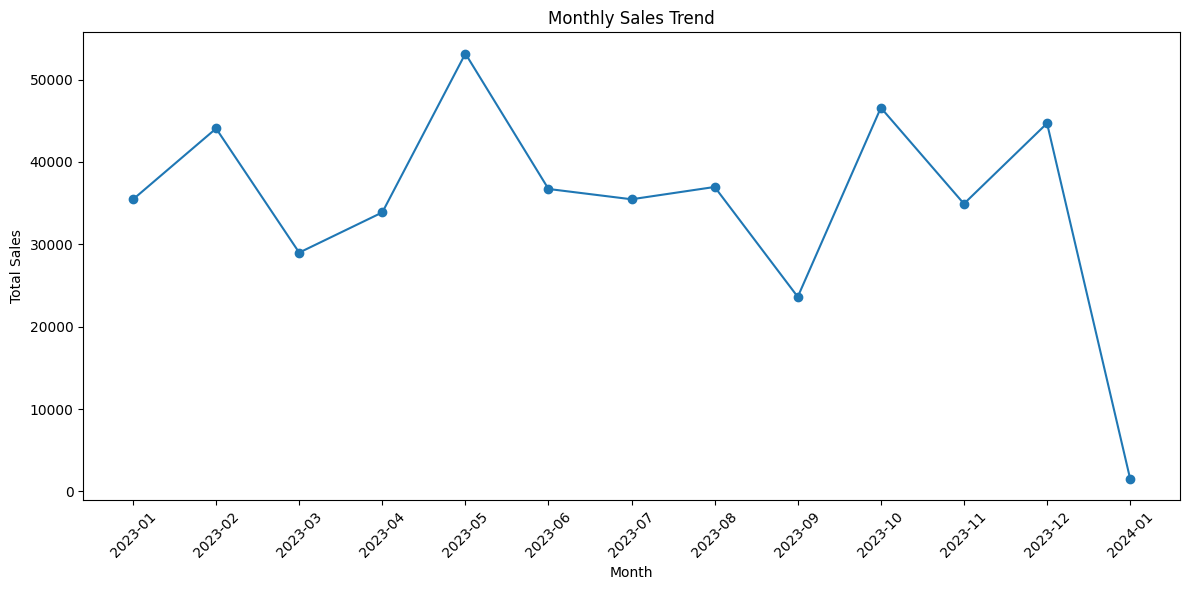

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The monthly sales trend shows considerable variation throughout the period. Sales reached their highest level in May 2023 at approximately 53,000, while the lowest sales occurred in January 2024. Significant increases can also be observed in October and December 2023, whereas September experienced a noticeable decline. These fluctuations suggest that the business may have seasonal or month-specific factors affecting sales performance.

In [9]:
df['Date'].max()
df[df['Date'].dt.to_period('M') == '2024-01'].shape

(2, 10)

In [10]:
print(df['Date'].max())
df[df['Date'].dt.to_period('M') == '2024-01']

2024-01-01 00:00:00


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
210,211,2024-01-01,CUST211,Male,42,Beauty,3,500,1500,2024-01
649,650,2024-01-01,CUST650,Male,55,Electronics,1,30,30,2024-01


In [11]:
# Create a quarter column
df['Quarter'] = df['Date'].dt.to_period('Q')

# Calculate total sales for each quarter
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

print(quarterly_sales)

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


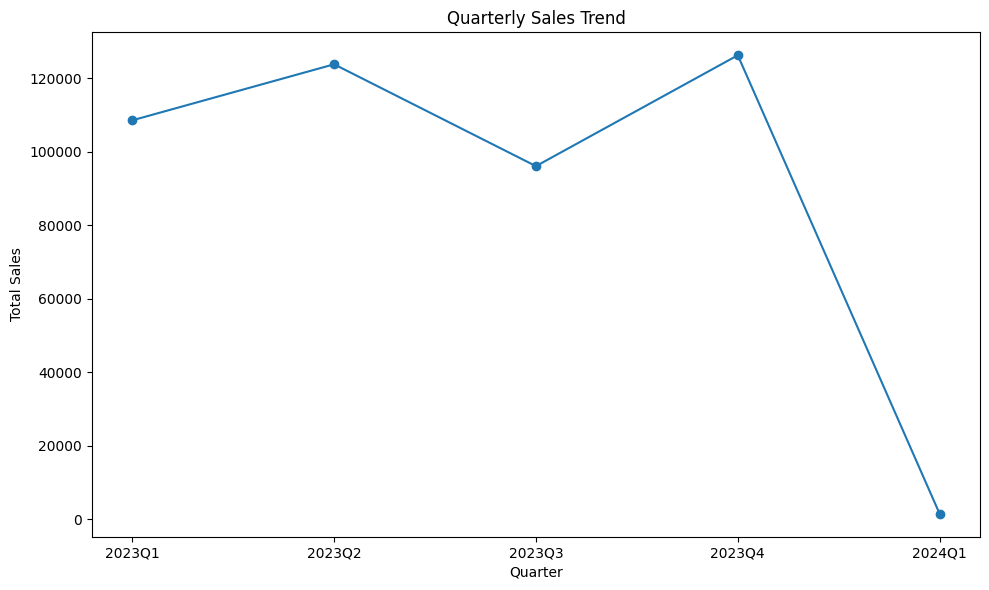

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(quarterly_sales.index.astype(str),
         quarterly_sales.values,
         marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

The quarterly sales trend shows fluctuations in sales performance throughout the period. Sales increased from Q1 to Q2 2023, declined in Q3, and reached their highest level in Q4 2023 at approximately 126,000. Q1 2024 shows unusually low sales because the dataset contains only two transactions in January 2024, making this quarter incomplete and unsuitable for direct comparison with the full quarters of 2023.

In [13]:
print("Minimum age:", df['Age'].min())
print("Maximum age:", df['Age'].max())

Minimum age: 18
Maximum age: 64


In [14]:
# Create age groups
bins = [17, 25, 35, 45, 55, 64]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

# Count customers in each age group
age_group_counts = df['Age Group'].value_counts().sort_index()

print(age_group_counts)

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-64    195
Name: count, dtype: int64


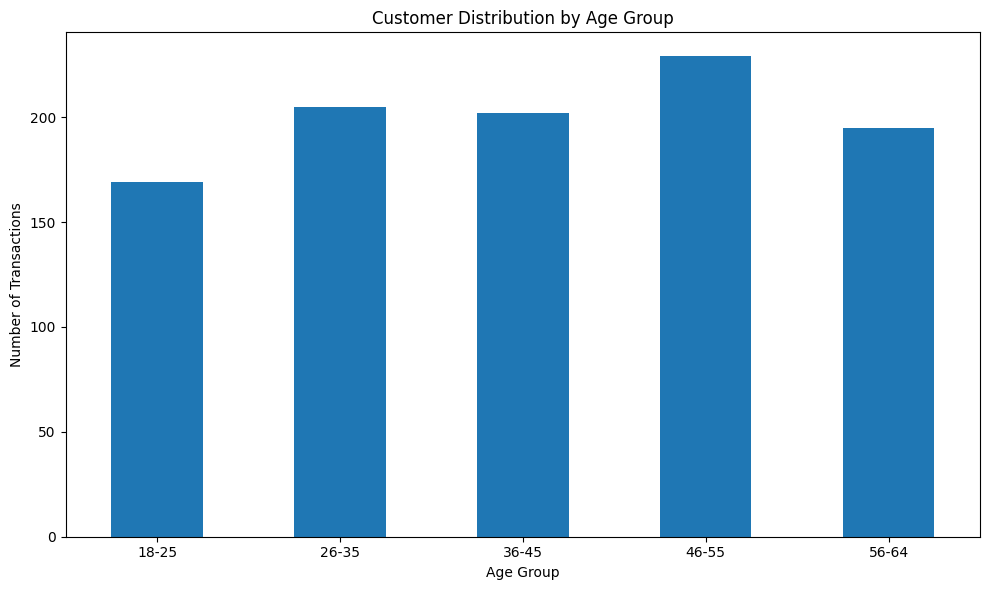

In [16]:
plt.figure(figsize=(10, 6))

age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Observation: The 46–55 age group represents the largest share of customers in the dataset, while the 18–25 group has the lowest representation. The 26–35, 36–45, and 56–64 groups have relatively similar customer counts. This indicates that the business has a broad customer base, with particularly strong participation from middle-aged customers.

In [17]:
gender_counts = df['Gender'].value_counts()

print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


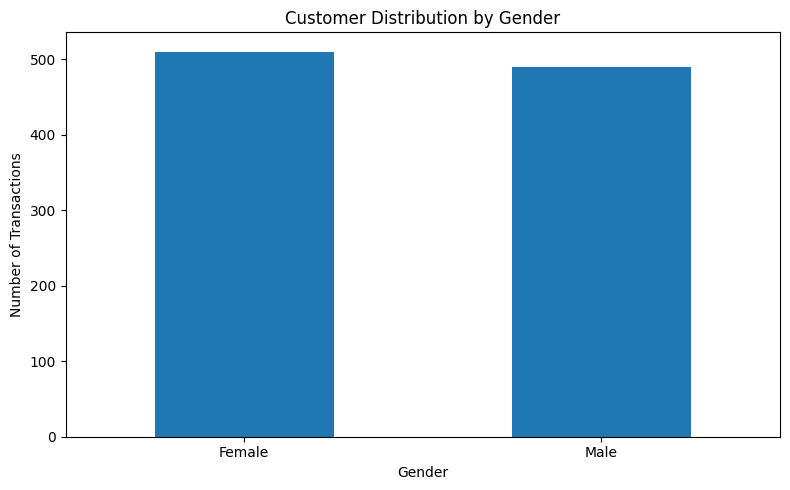

In [18]:
plt.figure(figsize=(8, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Observation: The gender distribution is relatively balanced, with female customers accounting for 510 transactions (51%) and male customers accounting for 490 transactions (49%). The small difference suggests that the business has a broad appeal across both gender groups rather than being strongly concentrated toward one gender.

In [19]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

print(category_quantity)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


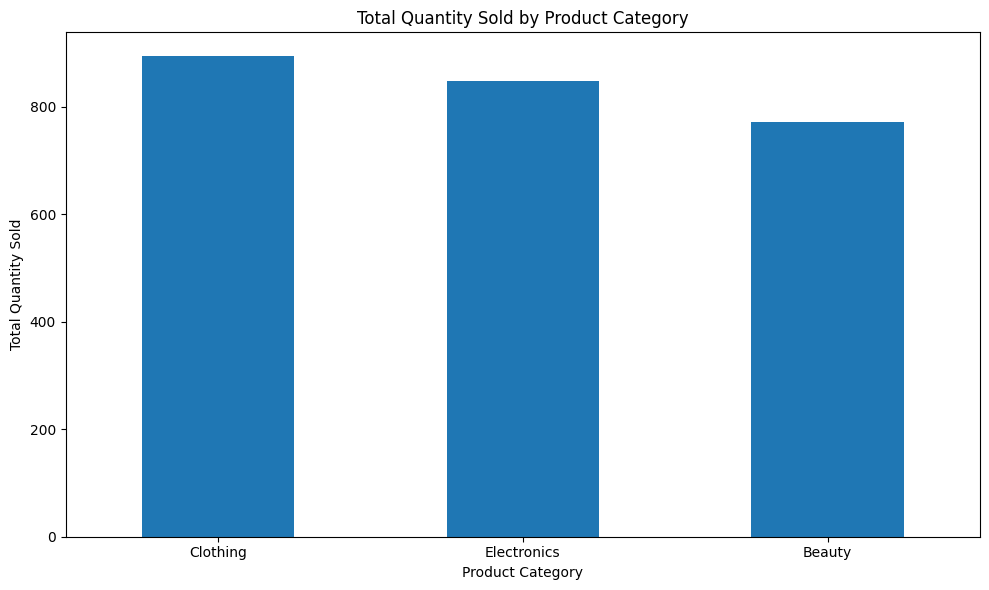

In [20]:
plt.figure(figsize=(10, 6))

category_quantity.plot(kind='bar')

plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Observation: Clothing has the highest total quantity sold among the three product categories, followed by Electronics and Beauty. The relatively strong sales volume of Clothing suggests that it is an important product category for the business. Beauty has the lowest quantity sold and may require further investigation to understand whether pricing, product selection, or customer demand is affecting its performance.

In [21]:
# Calculate total revenue for each product category
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print(category_revenue)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


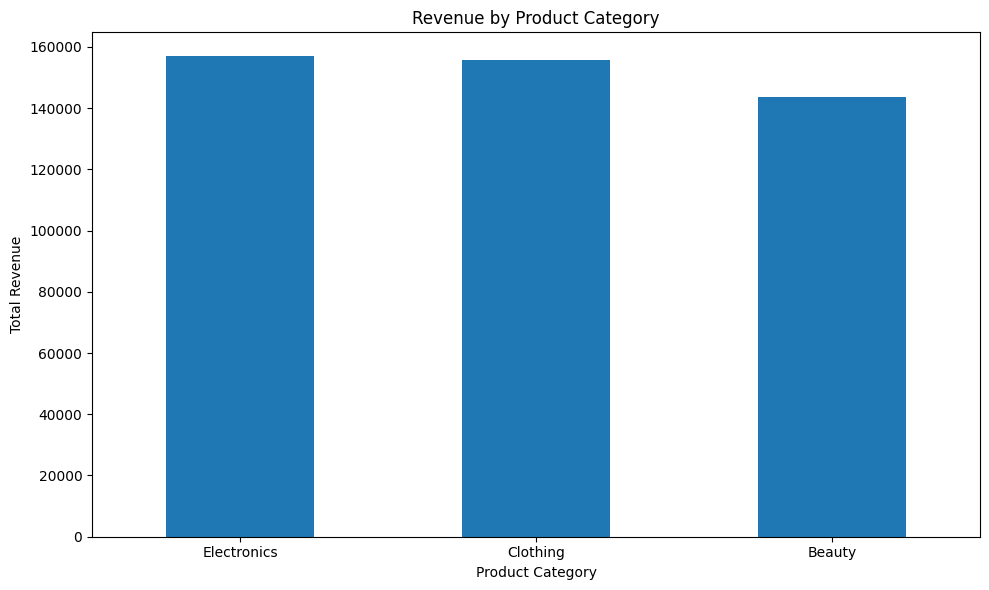

In [22]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Observation: Electronics generates the highest revenue among the three product categories, followed closely by Clothing. Although Clothing has the highest quantity sold, Electronics generates slightly more revenue, indicating that Electronics products may have a higher average selling price. Beauty has the lowest revenue and may have comparatively lower sales volume or pricing.

In [23]:
average_price = df.groupby('Product Category')['Total Amount'].sum() / df.groupby('Product Category')['Quantity'].sum()

print(average_price)

Product Category
Beauty         186.141375
Clothing       174.026846
Electronics    184.811543
dtype: float64


Additional Insight: Clothing has the highest sales volume but the lowest average revenue per unit among the three categories. Electronics generates the highest total revenue while maintaining a relatively high average revenue per unit. This suggests that the business should maintain strong Clothing sales while exploring opportunities to increase the average transaction value of Clothing products.

In [24]:
# Select numerical columns for correlation analysis
correlation_data = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


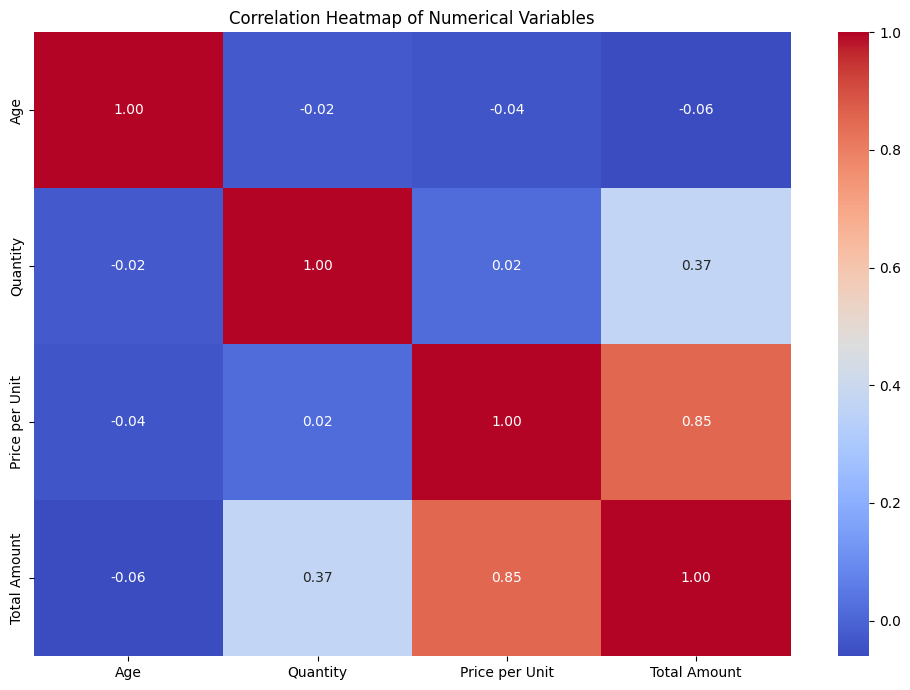

In [25]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.tight_layout()
plt.show()

Observation: The heatmap shows a strong positive correlation of 0.85 between Price per Unit and Total Amount, indicating that higher-priced items generally contribute to higher transaction values. Quantity has a moderate positive correlation of 0.37 with Total Amount, while Age has very weak correlations with Quantity, Price per Unit, and Total Amount. This suggests that transaction value is influenced more by product pricing and quantity than by customer age.

In [26]:
# Extract month from Date
df['Month'] = df['Date'].dt.to_period('M').astype(str)

# Calculate monthly revenue for each product category
monthly_category_sales = df.groupby(
    ['Month', 'Product Category']
)['Total Amount'].sum().unstack()

monthly_category_sales

Product Category,Beauty,Clothing,Electronics
Month,,,
2023-01,12430.0,13125.0,9895.0
2023-02,14035.0,14560.0,15465.0
2023-03,10545.0,15065.0,3380.0
2023-04,11905.0,13940.0,8025.0
2023-05,12450.0,17455.0,23245.0
2023-06,10995.0,10170.0,15550.0
2023-07,16090.0,8250.0,11125.0
2023-08,9790.0,12455.0,14715.0
2023-09,6320.0,9975.0,7325.0


<Figure size 1400x700 with 0 Axes>

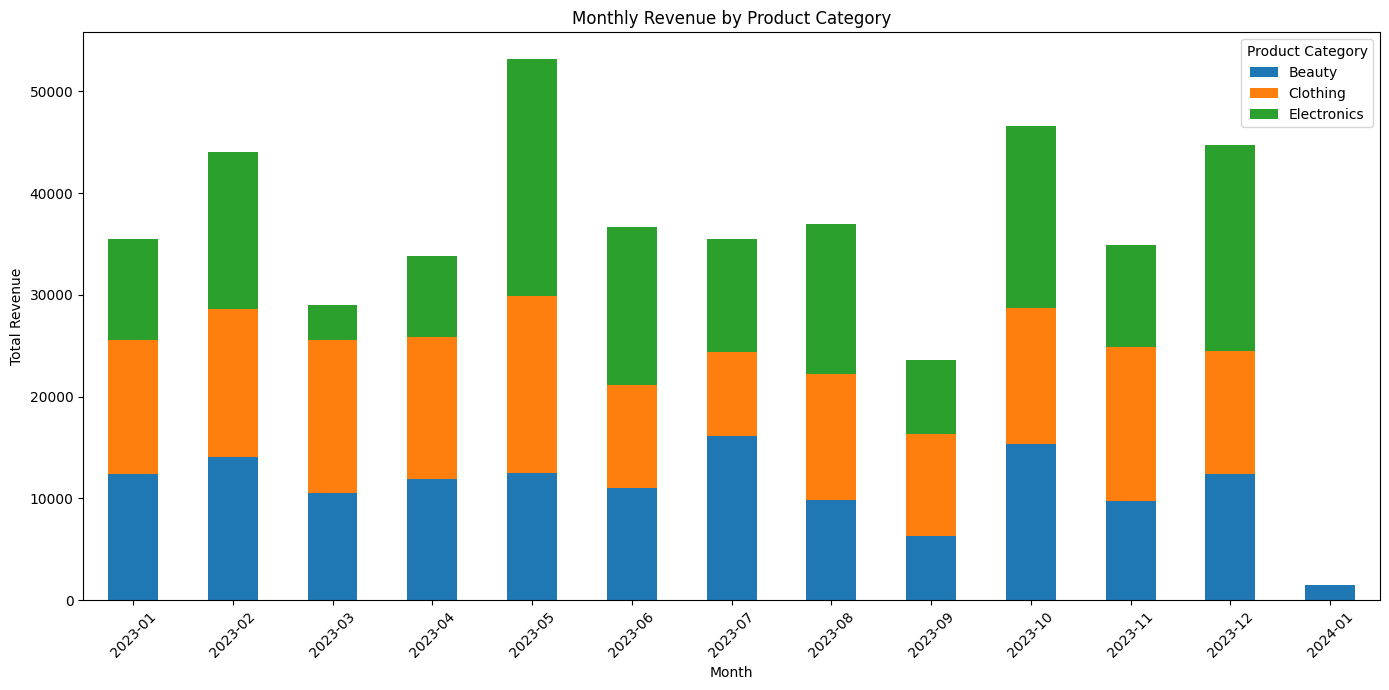

In [27]:
plt.figure(figsize=(14, 7))

monthly_category_sales.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Monthly Revenue by Product Category')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Observation: Monthly revenue varies considerably across product categories. May 2023 records the highest overall monthly revenue, with Electronics making a substantial contribution. Electronics also contributes strongly during October and December, while Beauty represents a larger share of revenue in some months such as July. These variations suggest that category-level demand changes over time, which can help the business plan inventory and promotional campaigns according to monthly demand patterns.

In [28]:
gender_revenue = df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False)

print("Revenue by Gender:")
print(gender_revenue)

Revenue by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


Observation: Female customers generated total revenue of 232,840 compared with 223,160 from male customers. Although female customers generated slightly higher revenue, the difference is relatively small, indicating that revenue is fairly balanced across genders. Therefore, marketing strategies should continue targeting both groups rather than focusing exclusively on one gender.

In [29]:
age_revenue = df.groupby('Age Group', observed=True)['Total Amount'].sum().sort_values(ascending=False)

print("\nRevenue by Age Group:")
print(age_revenue)


Revenue by Age Group:
Age Group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56-64     80410
Name: Total Amount, dtype: int64


Observation: Customers aged 46–55 generate the highest revenue at 100,690, followed closely by the 26–35 age group at 98,480. The 56–64 group generates the lowest revenue at 80,410. This suggests that middle-aged customers are an important revenue segment and could be targeted with personalized offers and product recommendations.

## Dataset Limitation

The dataset contains product categories but does not include individual product names. Therefore, a Top 10 Best-Selling Products analysis could not be performed. Instead, product category-level quantity and revenue analysis was performed.

# Business Recommendations

1. **Target the 46–55 age group:** This group generates the highest revenue, so personalized offers and loyalty campaigns can be used to increase repeat purchases.

2. **Strengthen Electronics sales:** Electronics generates the highest total revenue. The business should maintain sufficient inventory and use bundles or cross-selling to increase sales further.

3. **Improve Beauty category performance:** Beauty has the lowest quantity sold and revenue. The business should investigate pricing, product selection, and promotional strategies to improve demand.

4. **Plan inventory according to monthly demand:** Sales fluctuate significantly across months. Inventory and promotional campaigns should be planned around periods of stronger demand.

5. **Maintain strong Clothing inventory:** Clothing has the highest quantity sold, so the business should avoid stock shortages while exploring ways to increase its average revenue per unit.

# Conclusion

The exploratory data analysis revealed important patterns in retail sales, customer demographics, and product categories. Sales fluctuated across months and quarters, with strong performance during several periods in 2023.

Clothing recorded the highest quantity sold, while Electronics generated the highest total revenue. Customers aged 46–55 generated the highest revenue among the age groups. Revenue was relatively balanced between male and female customers.

The correlation analysis showed a strong positive relationship between Price per Unit and Total Amount, while Age had very weak relationships with the other numerical variables.

Overall, the analysis provides useful insights for customer targeting, inventory planning, product promotion, and improving the performance of lower-performing categories.